# MIX-MB Survey Analysis

Analysis of the **MIX-MB Community Survey** responses collected to inform minimum information standards for xenobiotic microbiome biotransformation data.

**File:** `MIX-MB Survey (Responses).xlsx`  
**Sections:**
1. Setup & Data Loading
2. Respondent Demographics
3. Current Data Practices
4. Research Challenges
5. Metadata Essentials — Biotransformation / Bioactivity
6. Metadata Essentials — Experiment
7. Metadata Essentials — Microbiome
8. Metadata Essentials — Xenobiotic / Chemical
9. Importance of Standardization
10. Barriers & Support Needs
11. Community Engagement
12. Open-ended Feedback

In [ ]:
#! pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── consistent style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

RATING_COLORS = {
    'Mandatory':    '#2166ac',
    'Recommended':  '#74add1',
    'Optional':     '#fed976',
    'Not needed':   '#d73027',
}
RATING_ORDER = ['Mandatory', 'Recommended', 'Optional', 'Not needed']

SURVEY_FILE = 'MIX-MB Survey (Responses).xlsx'
print('Libraries loaded.')

Libraries loaded.


## 1 · Setup & Data Loading

In [79]:
df = pd.read_excel(SURVEY_FILE, sheet_name='Form responses 1')

# Friendly short column names (keep originals in df.columns for reference)
COL = {
    'timestamp'        : df.columns[0], # Time stamp of survey submission
    'research_area'    : df.columns[1], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'role'             : df.columns[2], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'experience'       : df.columns[3], # certain options: should be sequential: more than 12 years,  8-12, 4-7, 1-3, less than 1
    'microbiome_field' : df.columns[4], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'region'           : df.columns[5], # certain options
    'data_submitted'   : df.columns[6], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'follows_standards': df.columns[7], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'known_standards'  : df.columns[8], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    'challenges'       : df.columns[9], # certain options and  open text, with sepcial characters likle / . , ( ) - ?  etc.
    # Biotransformation/Bioactivity (cols 10-16) all columns have mandatory, recommended, optional, not needed options
    'bt_assay_type'       : df.columns[10],
    'bt_activity_value'   : df.columns[11],
    'bt_std_values_units' : df.columns[12],
    'bt_lack_activity'    : df.columns[13],
    'bt_reaction_type'    : df.columns[14],
    'bt_metabolite_annot' : df.columns[15],
    'bt_kinetic_params'   : df.columns[16],
    'bt_freetext'         : df.columns[17],  # open text
    # Experiment (cols 18-31) all columns have mandatory, recommended, optional, not needed options
    'ex_oxygen'       : df.columns[18],
    'ex_media'        : df.columns[19],
    'ex_temperature'  : df.columns[20],
    'ex_shaking'      : df.columns[21],
    'ex_neg_controls' : df.columns[22],
    'ex_preculture'   : df.columns[23],
    'ex_antibiotic'   : df.columns[24],
    'ex_biomass_start': df.columns[25],
    'ex_duration'     : df.columns[26],
    'ex_timecourse'   : df.columns[27],
    'ex_biomass_end'  : df.columns[28],
    'ex_storage'      : df.columns[29],
    'ex_sample_prep'  : df.columns[30],
    'ex_instrument'   : df.columns[31],
    'ex_freetext'     : df.columns[32],  # open text
    # Microbiome (cols 33-42) all columns have mandatory, recommended, optional, not needed options
    'mb_source'       : df.columns[33],
    'mb_vendor'       : df.columns[34],
    'mb_sci_name'     : df.columns[35],
    'mb_ncbi_tax'     : df.columns[36],
    'mb_human_donor'  : df.columns[37],
    'mb_env_meta'     : df.columns[38],
    'mb_tissue'       : df.columns[39],
    'mb_protein'      : df.columns[40],
    'mb_gene'         : df.columns[41],
    'mb_uniprot'      : df.columns[42],
    'mb_freetext'     : df.columns[43],  # open text
    # Xenobiotic/Chemical (cols 44-58) all columns have mandatory, recommended, optional, not needed options
    'xb_common_name'  : df.columns[44],
    'xb_iupac'        : df.columns[45],
    'xb_smiles'       : df.columns[46],
    'xb_sdf'          : df.columns[47],
    'xb_identifier'   : df.columns[48],
    'xb_cas'          : df.columns[49],
    'xb_vendor'       : df.columns[50],
    'xb_purity'       : df.columns[51],
    'xb_solubility'   : df.columns[52],
    'xb_stock_conc'   : df.columns[53],
    'xb_stock_solvent': df.columns[54],
    'xb_mol_formula'  : df.columns[55],
    'xb_mol_weight'   : df.columns[56],
    'xb_mono_mass'    : df.columns[57],
    'xb_column_sep'   : df.columns[58],
    'xb_freetext'     : df.columns[59],  # open text
    # General
    'importance'      : df.columns[60], # number scale 1-5, with 5 = strongly agree, 1 = strongly disagree
    'barriers'        : df.columns[61], # certain options and open text
    'benefit_guide'   : df.columns[62], # number scale 1-5, with 5 = strongly agree, 1 = strongly disagree
    'support_type'    : df.columns[63], # certain options and open text
    'new_standards'   : df.columns[64], # open text
    'specific_features': df.columns[65], # open text
    'contact_ok'      : df.columns[66], # Yes, No, Maybe
    'contribute'      : df.columns[67], # Yes, No, Maybe
    'email'           : df.columns[68], # email format
}

# ── dtype casting ──────────────────────────────────────────────────────────────────────────────

# Numeric 1-5 scale columns -> nullable integer
for _key in ['importance', 'benefit_guide']:
    df[COL[_key]] = pd.to_numeric(df[COL[_key]], errors='coerce').astype('Int64')

# Rating columns -> ordered categorical (strips whitespace, enforces valid values)
RATING_CAT = pd.CategoricalDtype(categories=RATING_ORDER, ordered=True)
_RATING_KEYS = [
    'bt_assay_type', 'bt_activity_value', 'bt_std_values_units', 'bt_lack_activity',
    'bt_reaction_type', 'bt_metabolite_annot', 'bt_kinetic_params',
    'ex_oxygen', 'ex_media', 'ex_temperature', 'ex_shaking', 'ex_neg_controls',
    'ex_preculture', 'ex_antibiotic', 'ex_biomass_start', 'ex_duration',
    'ex_timecourse', 'ex_biomass_end', 'ex_storage', 'ex_sample_prep', 'ex_instrument',
    'mb_source', 'mb_vendor', 'mb_sci_name', 'mb_ncbi_tax', 'mb_human_donor',
    'mb_env_meta', 'mb_tissue', 'mb_protein', 'mb_gene', 'mb_uniprot',
    'xb_common_name', 'xb_iupac', 'xb_smiles', 'xb_sdf', 'xb_identifier',
    'xb_cas', 'xb_vendor', 'xb_purity', 'xb_solubility', 'xb_stock_conc',
    'xb_stock_solvent', 'xb_mol_formula', 'xb_mol_weight', 'xb_mono_mass', 'xb_column_sep',
]
for _key in _RATING_KEYS:
    df[COL[_key]] = df[COL[_key]].str.strip().astype(RATING_CAT)

# Experience -> ordered categorical (sequential: junior to senior)
EXPERIENCE_ORDER = ['Less than 1 year', '1-3 years', '4-7 years', '8-12 years', 'More than 12 years']
df[COL['experience']] = pd.Categorical(
    df[COL['experience']].str.strip(),
    categories=EXPERIENCE_ORDER,
    ordered=True,
)

print(f'Responses loaded: {len(df)} rows x {len(df.columns)} columns')
print(f'Date range: {df[COL["timestamp"]].min().date()} -> {df[COL["timestamp"]].max().date()}')
df.head(2)

Responses loaded: 25 rows x 69 columns
Date range: 2026-02-09 -> 2026-03-05


,Timestamp,What is your primary research area?,What is your primary role?,Years of experience in microbiome research:,Which microbiome field you work in?,Geographic region of your institution:,Which data do you submit to repositories?,Do you follow standardized data formats and metadata standards in your work?,Which data standards are you currently using or know about? (Select all that apply),What are the biggest challenges in your microbiome research? (Select up to 3),...,[Xenobiotic/ Chemical edition] Please mention additional important parameters if they are not mentioned above.,How important are standardized metadata and data formats for your research? (1-5 scale),What barriers prevent you from adopting standardized data formats? (Select all that apply),Would you benefit from guidelines and templates for implementing microbiome data standards?,What type of support would most help you implement standards in your research? (Select top 3),What new standards or guidelines do you think the microbiome research community needs?,What specific features would help you implement and maintain data standards?,May we contact you for follow-up discussions or future surveys?,Would you like to participate/ contribute to this resource?,Please enter your email if you would like to be contacted and if you would like to contribute.
0,2026-02-15 19:43:40.286,Microbiology/ Microbiome,Principal Investigator,More than 12 years,"Human (Gut, Skin, Oral, etc.), Animal Microbio...",Europe,"Sequencing data (i.e., EMBL-EBI (ENA) / NCBI (...","Yes, consistently",FAIR principles,"Data quality and standardization, Lack of stan...",...,NaN,5,Lack of awareness/knowledge,5,"Community discussion forums, Publication guide...",NaN,NaN,Yes,Yes,schloter@tum.de
1,2026-02-12 11:39:20.078,Bioinformatics/ Cheminformtics,PhD Student,Less than 1 year,Animal Microbiome (excluding human),Europe,"Sequencing data (i.e., EMBL-EBI (ENA) / NCBI (...","Yes, consistently","FAIR principles, STREAMS guidelines, MIxS stan...","Data quality and standardization, Analysis met...",...,NaN,5,"Lack of awareness/knowledge, Time requirements...",5,"Detailed documentation and tutorials, Example ...",NaN,NaN,Yes,Yes,luka.velasevic@embl.de


## 2 · Respondent Demographics

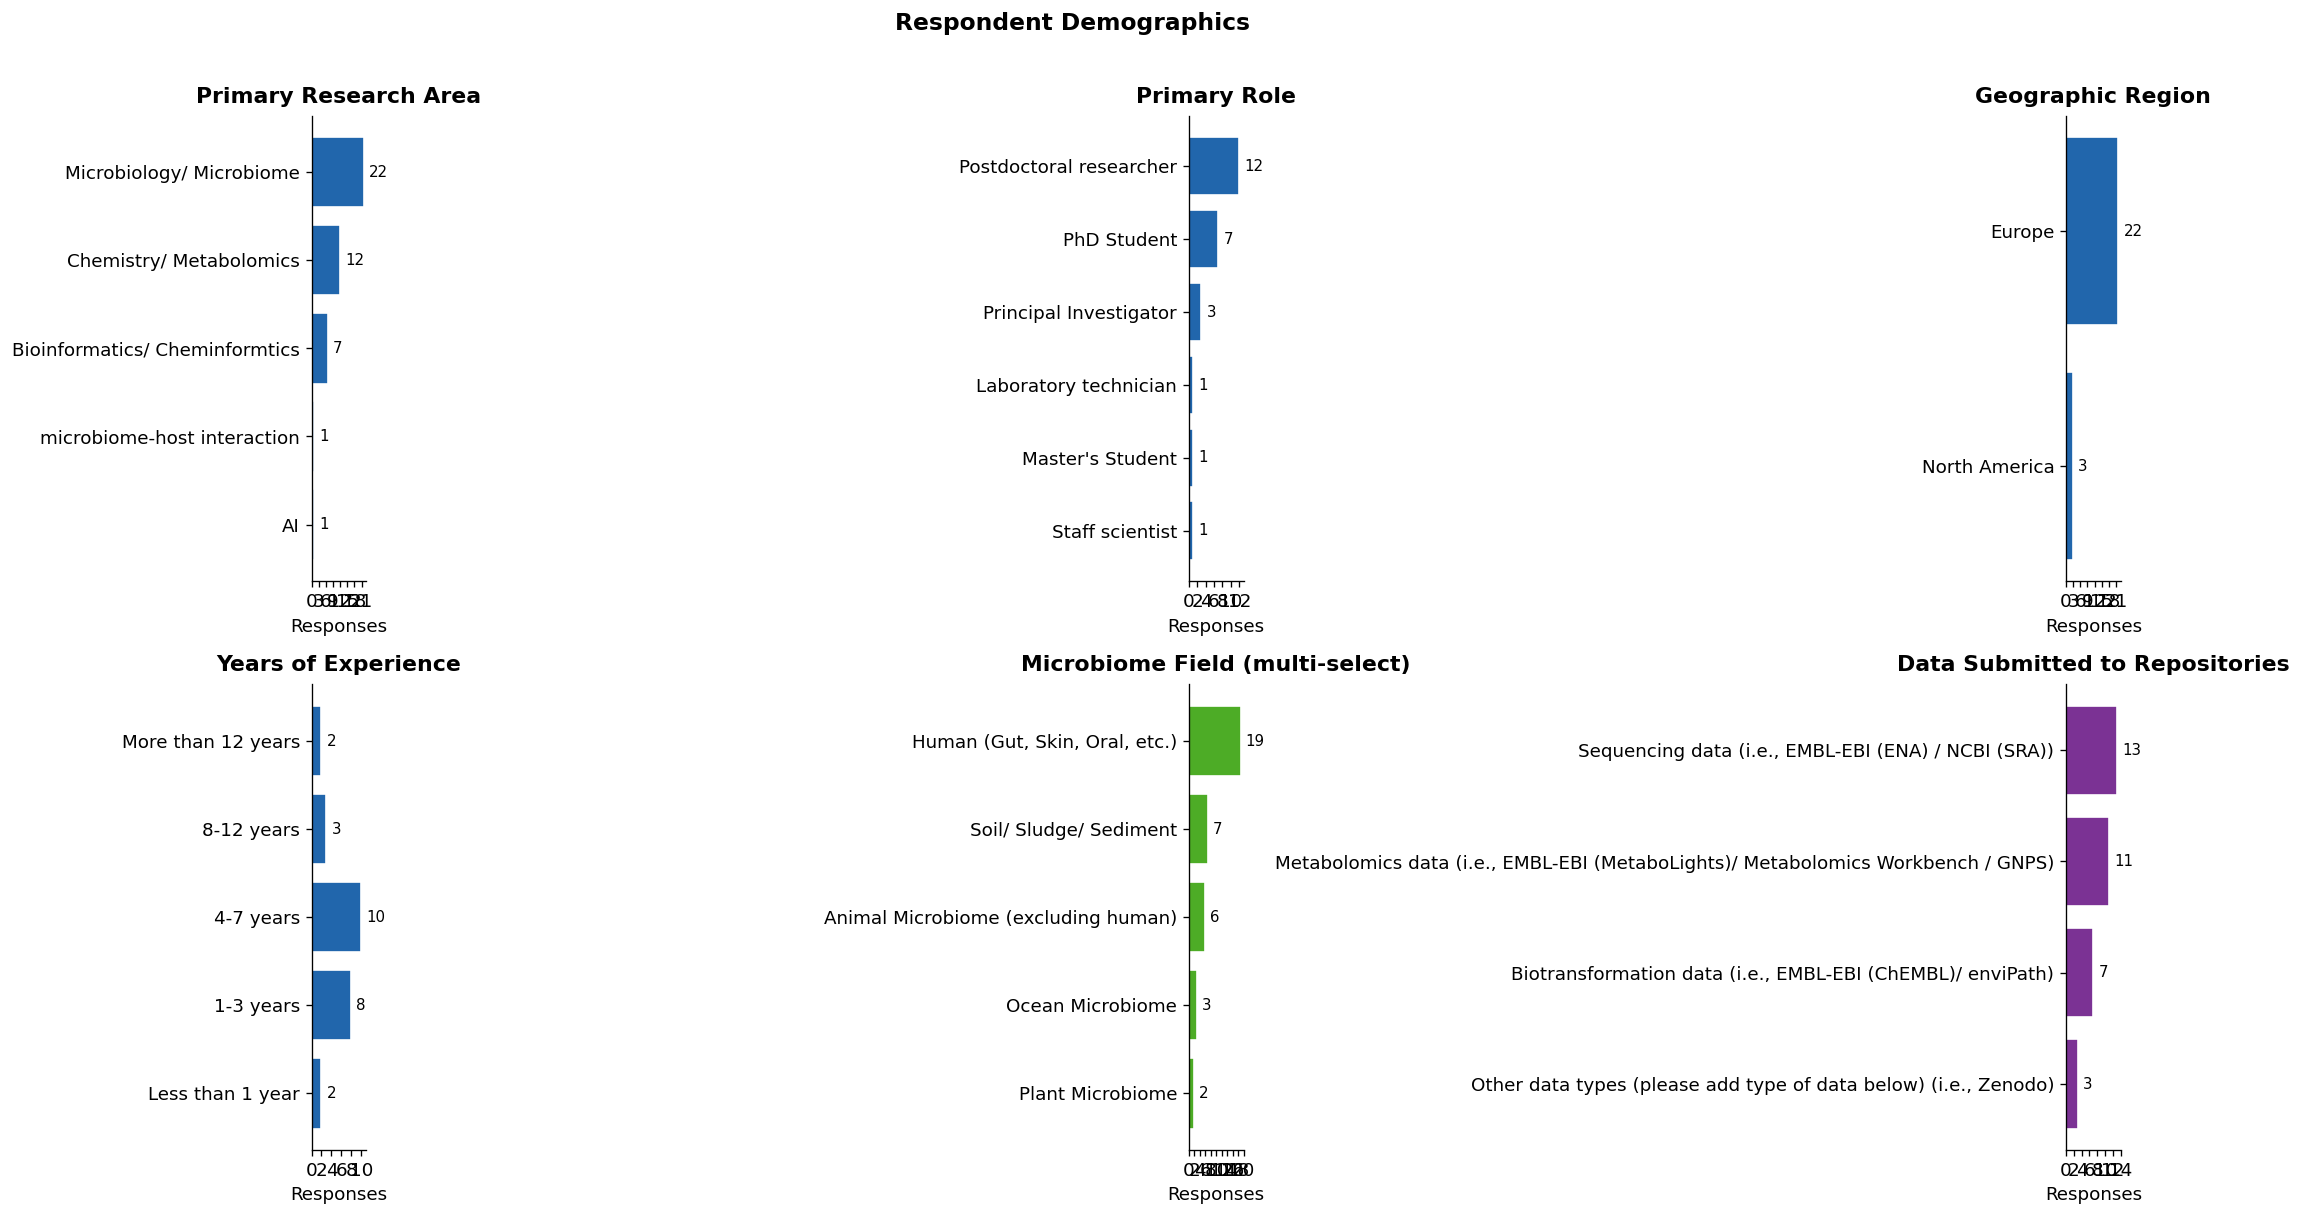

In [80]:
def split_multi(series, sep=','):
    """Explode comma-separated multi-select answers into individual items."""
    return (
        series.dropna()
        .str.split(sep)
        .explode()
        .str.strip()
    )

def split_known_options(series, known_options, other_label=None):
    """Match known multi-select option strings against each response.

    Use this instead of split_multi when options contain commas themselves
    (e.g. 'Human (Gut, Skin, Oral, etc.)').
    If other_label is set, any remaining text after removing matched options
    is counted under that label, capturing free-text 'Other' entries.
    """
    result = []
    for val in series.dropna():
        remaining = str(val)
        for opt in known_options:
            if opt in remaining:
                result.append(opt)
                remaining = remaining.replace(opt, '')
        if other_label is not None:
            remaining = remaining.replace(',', '').strip()
            if remaining:
                result.append(other_label)
    return pd.Series(result)

def get_other_texts(series, known_options):
    """Return the actual free-text entries left after removing known options."""
    others = []
    for val in series.dropna():
        remaining = str(val)
        for opt in known_options:
            remaining = remaining.replace(opt, '')
        remaining = remaining.replace(',', '').strip()
        if remaining:
            others.append(remaining)
    return others

MICROBIOME_FIELD_OPTIONS = [
    'Human (Gut, Skin, Oral, etc.)',
    'Animal Microbiome (excluding human)',
    'Soil/ Sludge/ Sediment',
    'Ocean Microbiome',
    'Plant Microbiome',
]

DATA_SUBMITTED_OPTIONS = [
    'Sequencing data (i.e., EMBL-EBI (ENA) / NCBI (SRA))',
    'Metabolomics data (i.e., EMBL-EBI (MetaboLights)/ Metabolomics Workbench / GNPS)',
    'Biotransformation data (i.e., EMBL-EBI (ChEMBL)/ enviPath)',
    'Other data types (please add type of data below) (i.e., Zenodo)',
    'None',
    'Other',
]

CHALLENGES_OPTIONS = [
    'Data quality and standardization',
    'Analysis method selection and validation',
    'Data storage and management',
    'Computational resources',
    'Lack of standardized reference databases',
    'Collaboration and data sharing',
    'Interpretation of results',
    'Funding limitations',
]

BARRIERS_OPTIONS = [
    'Lack of awareness/knowledge',
    'Complexity of standards',
    'Time requirements for implementation',
    'Incompatibility with existing workflows',
    'Lack of institutional support',
    'No perceived benefit',
    "Standards don't fit our research needs",
    'We already follow standards',
]

SUPPORT_TYPE_OPTIONS = [
    'Training workshops/webinars',
    'Detailed documentation and tutorials',
    'Software tools that enforce standards',
    'Consultation with standards experts',
    'Example datasets and use cases',
    'Community discussion forums',
    'Institutional incentives/mandates',
    'Publication guidelines requiring standards',
]

def bar_h(counts, title, ax, color='#2166ac', xlabel='Responses', sort=True):
    if sort:
        counts = counts.sort_values()
    bars = ax.barh(counts.index, counts.values, color=color, edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, max(counts.values) + 1)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Respondent Demographics', fontsize=14, fontweight='bold', y=1.01)

demo_cols = [
    ('research_area', 'Primary Research Area'),
    ('role',          'Primary Role'),
    ('region',        'Geographic Region'),
]

# Research area, Role, Region — single-select
for ax, (key, title) in zip(axes.flat[:3], demo_cols):
    counts = split_multi(df[COL[key]]).value_counts()
    bar_h(counts, title, ax)

# Experience — ordered categorical: show in sequential order (junior → senior)
ax = axes.flat[3]
counts = df[COL['experience']].value_counts().reindex(EXPERIENCE_ORDER)
bar_h(counts, 'Years of Experience', ax, sort=False)

# Microbiome field — multi-select with commas inside option names
ax = axes.flat[4]
counts = split_known_options(df[COL['microbiome_field']], MICROBIOME_FIELD_OPTIONS).value_counts()
bar_h(counts, 'Microbiome Field (multi-select)', ax, color='#4dac26')

# Data submitted — multi-select with commas inside option names
ax = axes.flat[5]
counts = split_known_options(df[COL['data_submitted']], DATA_SUBMITTED_OPTIONS).value_counts()
bar_h(counts, 'Data Submitted to Repositories', ax, color='#7b3294')

plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight')
plt.show()

## 3 · Current Data Practices

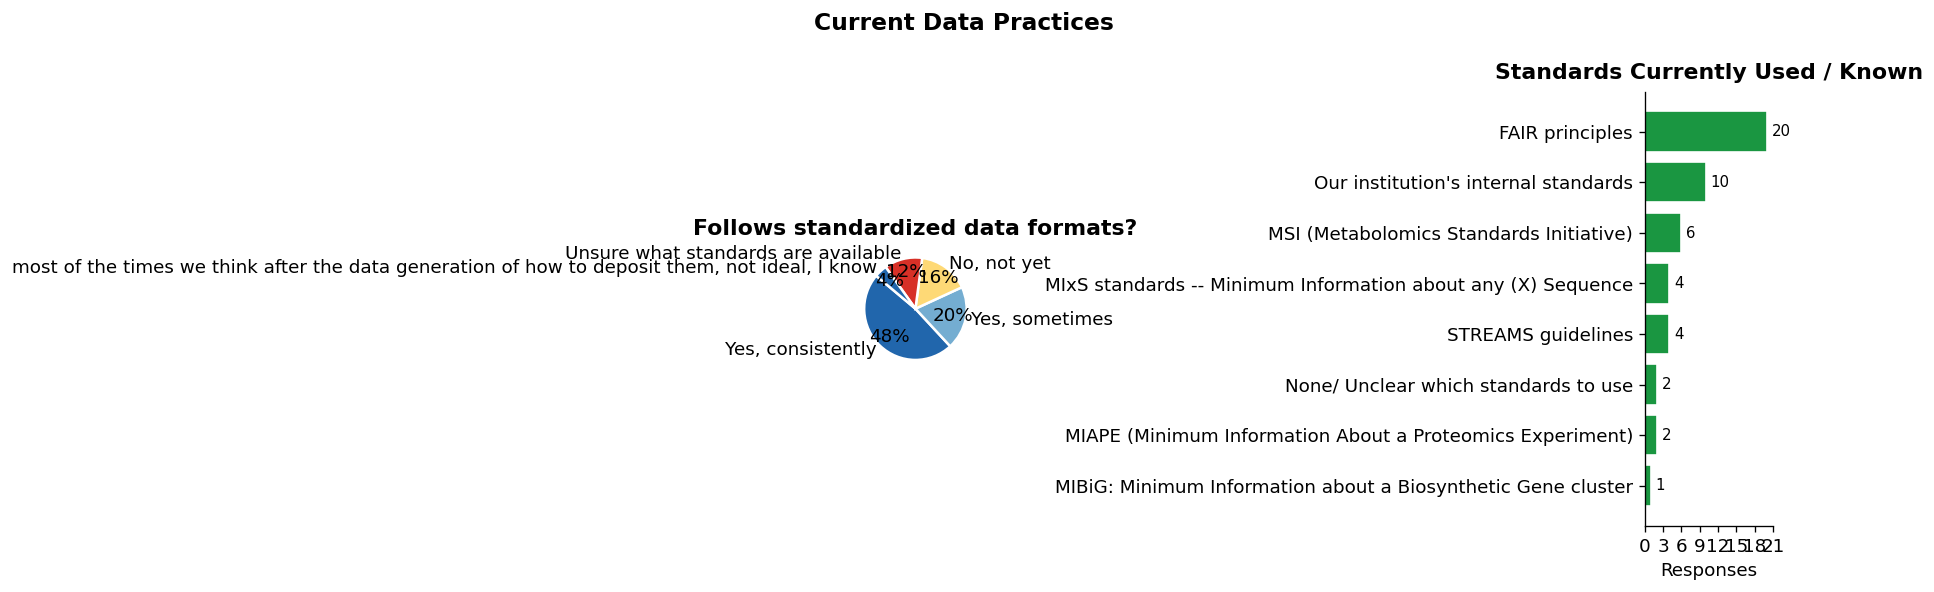

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Current Data Practices', fontsize=14, fontweight='bold')

# Follows standards?
ax = axes[0]
counts = df[COL['follows_standards']].value_counts()
wedge_colors = ['#2166ac', '#74add1', '#fed976', '#d73027']
ax.pie(counts.values, labels=counts.index, colors=wedge_colors[:len(counts)],
       autopct='%1.0f%%', startangle=140, pctdistance=0.75,
       wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Follows standardized data formats?', fontweight='bold')

# Known standards — multi-select
ax = axes[1]
counts = split_multi(df[COL['known_standards']]).value_counts()
bar_h(counts, 'Standards Currently Used / Known', ax, color='#1a9641')

plt.tight_layout()
plt.savefig('fig_data_practices.png', bbox_inches='tight')
plt.show()

## 4 · Research Challenges

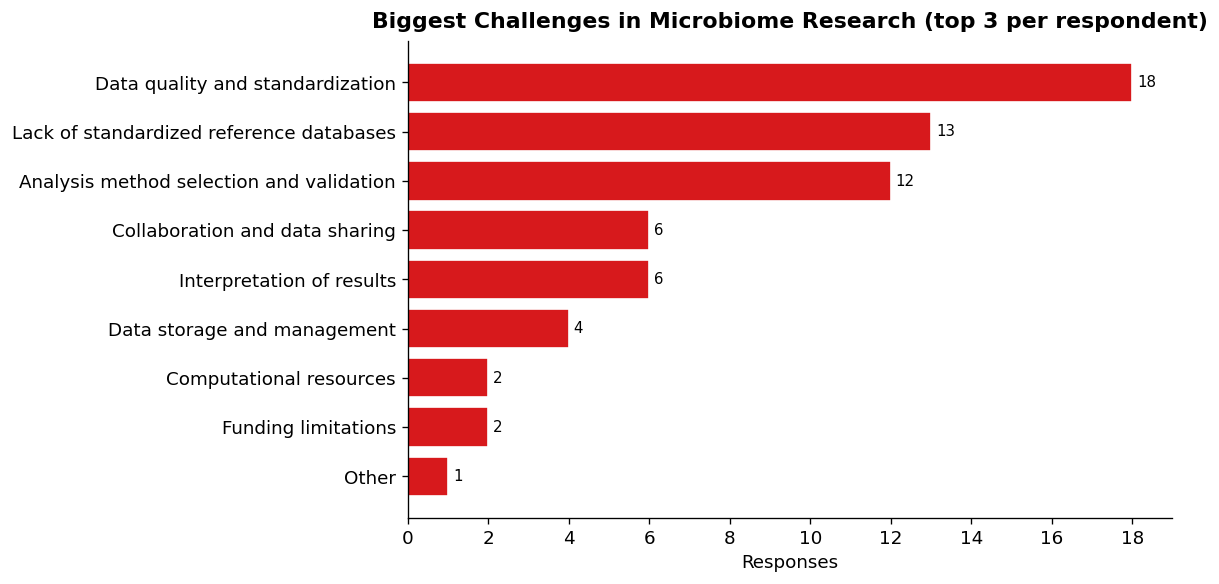


Other challenge responses:
  - The lab-specific variation in 16S and metagenome analysis which is known to all but mostly ignored


In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
counts = split_known_options(df[COL['challenges']], CHALLENGES_OPTIONS, other_label='Other').value_counts()
bar_h(counts, 'Biggest Challenges in Microbiome Research (top 3 per respondent)', ax, color='#d7191c')
plt.tight_layout()
plt.savefig('fig_challenges.png', bbox_inches='tight')
plt.show()

# Print free-text 'Other' responses
_others = get_other_texts(df[COL['challenges']], CHALLENGES_OPTIONS)
if _others:
    print('\nOther challenge responses:')
    for _t in _others:
        print(f'  - {_t}')

## 5 · Metadata Essentials — Biotransformation / Bioactivity

Each parameter was rated as **Mandatory**, **Recommended**, **Optional**, or **Not needed**.

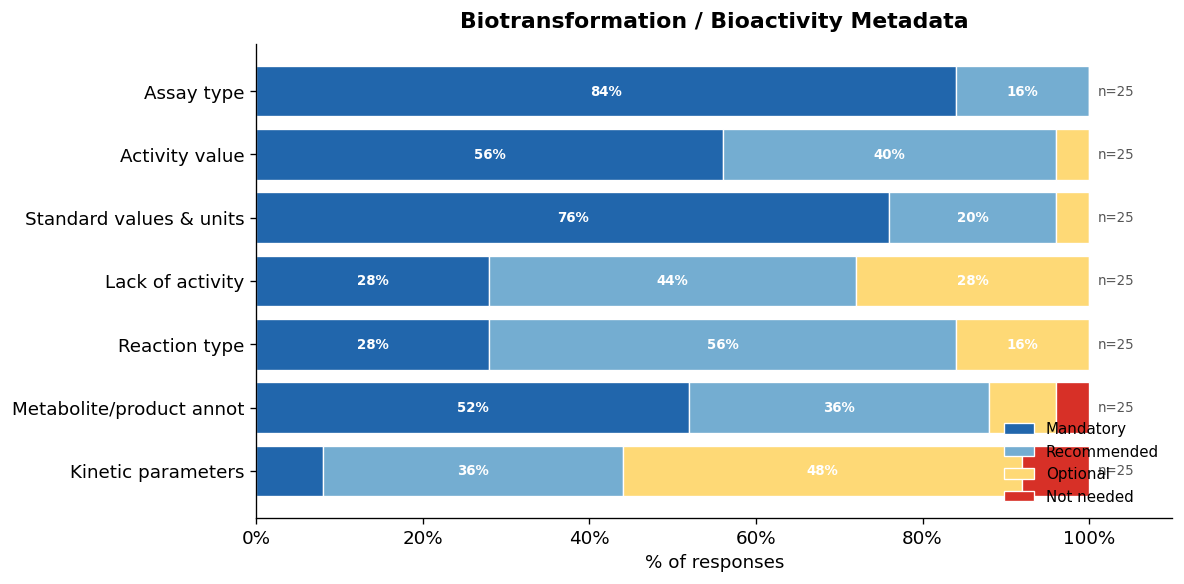

In [83]:
def rating_stacked_bar(col_map, title, figsize=(10, 5)):
    """
    col_map: dict of {short_label: df_column_name}
    Plots a 100% stacked horizontal bar chart for Mandatory/Recommended/Optional/Not needed.
    """
    # Build count matrix
    labels = list(col_map.keys())
    data = {r: [] for r in RATING_ORDER}
    for col in col_map.values():
        vc = df[col].value_counts()
        for r in RATING_ORDER:
            data[r].append(vc.get(r, 0))

    counts_df = pd.DataFrame(data, index=labels)
    pct_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=figsize)
    left = np.zeros(len(labels))
    for r in RATING_ORDER:
        vals = pct_df[r].values
        bars = ax.barh(labels, vals, left=left,
                       color=RATING_COLORS.get(r, '#aaa'),
                       label=r, edgecolor='white', linewidth=0.8)
        # Annotate segments > 8%
        for i, (v, l) in enumerate(zip(vals, left)):
            if v > 8:
                ax.text(l + v / 2, i, f'{v:.0f}%',
                        ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        left += vals

    # Raw counts annotation on the right
    for i, lbl in enumerate(labels):
        n = counts_df.loc[lbl].sum()
        ax.text(101, i, f'n={n}', va='center', fontsize=8, color='#555')

    ax.set_xlim(0, 110)
    ax.set_xlabel('% of responses')
    ax.set_title(title, fontweight='bold', pad=10)
    ax.legend(loc='lower right', frameon=False, fontsize=9)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.invert_yaxis()
    plt.tight_layout()
    return fig, ax


BT_COLS = {
    'Assay type'              : COL['bt_assay_type'],
    'Activity value'          : COL['bt_activity_value'],
    'Standard values & units' : COL['bt_std_values_units'],
    'Lack of activity'        : COL['bt_lack_activity'],
    'Reaction type'           : COL['bt_reaction_type'],
    'Metabolite/product annot': COL['bt_metabolite_annot'],
    'Kinetic parameters'      : COL['bt_kinetic_params'],
}

fig, ax = rating_stacked_bar(BT_COLS, 'Biotransformation / Bioactivity Metadata', figsize=(10, 5))
plt.savefig('fig_metadata_bioactivity.png', bbox_inches='tight')
plt.show()

## 6 · Metadata Essentials — Experiment

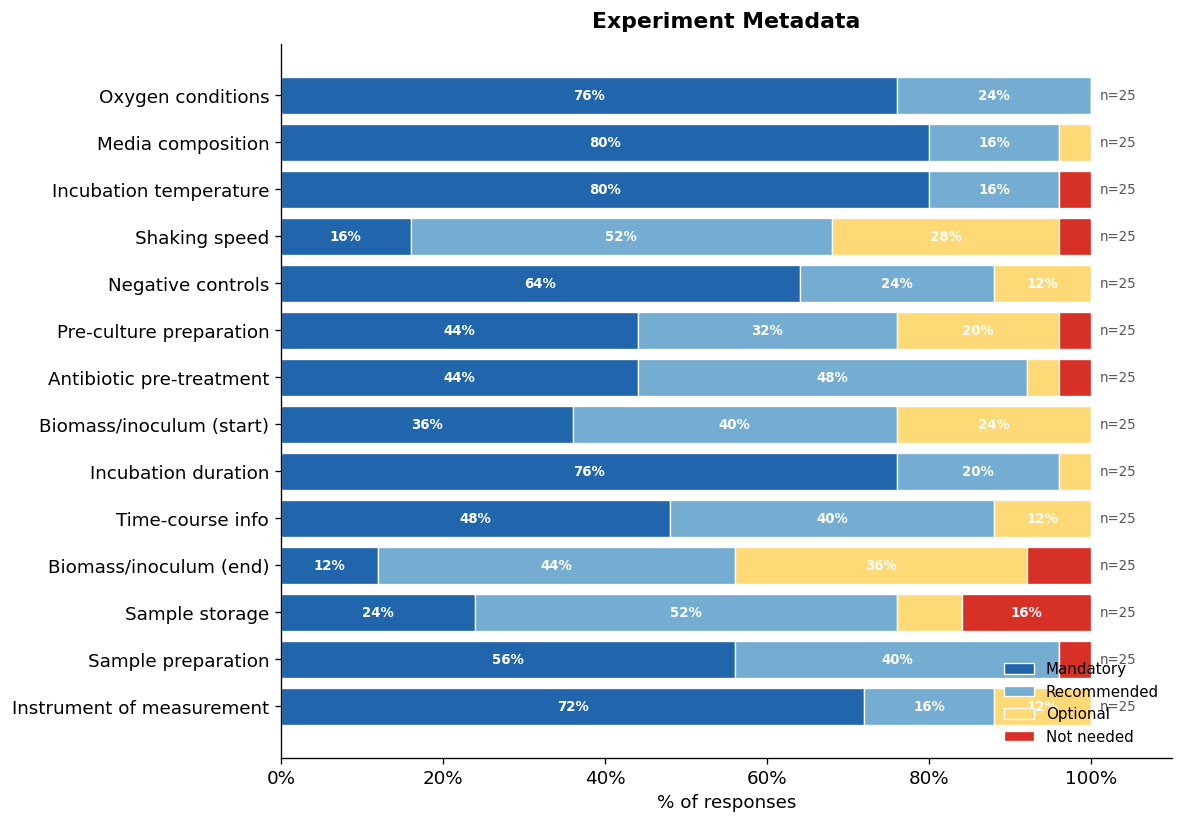

In [84]:
EX_COLS = {
    'Oxygen conditions'       : COL['ex_oxygen'],
    'Media composition'       : COL['ex_media'],
    'Incubation temperature'  : COL['ex_temperature'],
    'Shaking speed'           : COL['ex_shaking'],
    'Negative controls'       : COL['ex_neg_controls'],
    'Pre-culture preparation' : COL['ex_preculture'],
    'Antibiotic pre-treatment': COL['ex_antibiotic'],
    'Biomass/inoculum (start)': COL['ex_biomass_start'],
    'Incubation duration'     : COL['ex_duration'],
    'Time-course info'        : COL['ex_timecourse'],
    'Biomass/inoculum (end)'  : COL['ex_biomass_end'],
    'Sample storage'          : COL['ex_storage'],
    'Sample preparation'      : COL['ex_sample_prep'],
    'Instrument of measurement': COL['ex_instrument'],
}

fig, ax = rating_stacked_bar(EX_COLS, 'Experiment Metadata', figsize=(10, 7))
plt.savefig('fig_metadata_experiment.png', bbox_inches='tight')
plt.show()

## 7 · Metadata Essentials — Microbiome

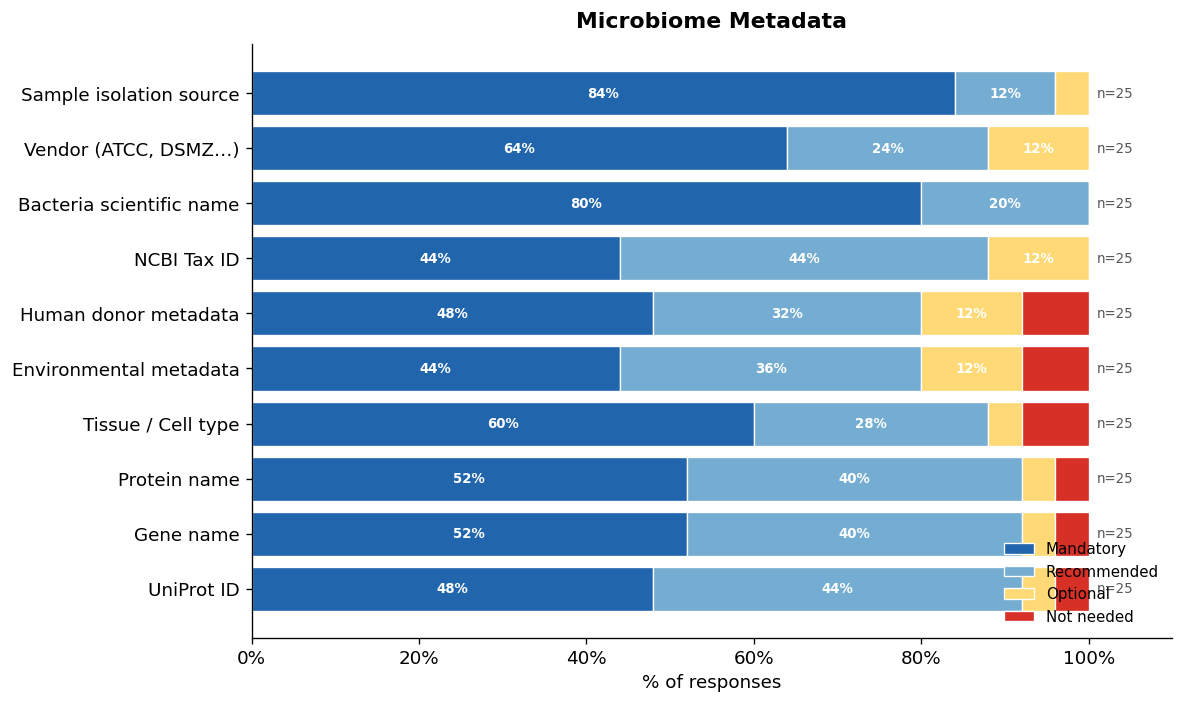

In [85]:
MB_COLS = {
    'Sample isolation source' : COL['mb_source'],
    'Vendor (ATCC, DSMZ…)'    : COL['mb_vendor'],
    'Bacteria scientific name': COL['mb_sci_name'],
    'NCBI Tax ID'             : COL['mb_ncbi_tax'],
    'Human donor metadata'    : COL['mb_human_donor'],
    'Environmental metadata'  : COL['mb_env_meta'],
    'Tissue / Cell type'      : COL['mb_tissue'],
    'Protein name'            : COL['mb_protein'],
    'Gene name'               : COL['mb_gene'],
    'UniProt ID'              : COL['mb_uniprot'],
}

fig, ax = rating_stacked_bar(MB_COLS, 'Microbiome Metadata', figsize=(10, 6))
plt.savefig('fig_metadata_microbiome.png', bbox_inches='tight')
plt.show()

## 8 · Metadata Essentials — Xenobiotic / Chemical

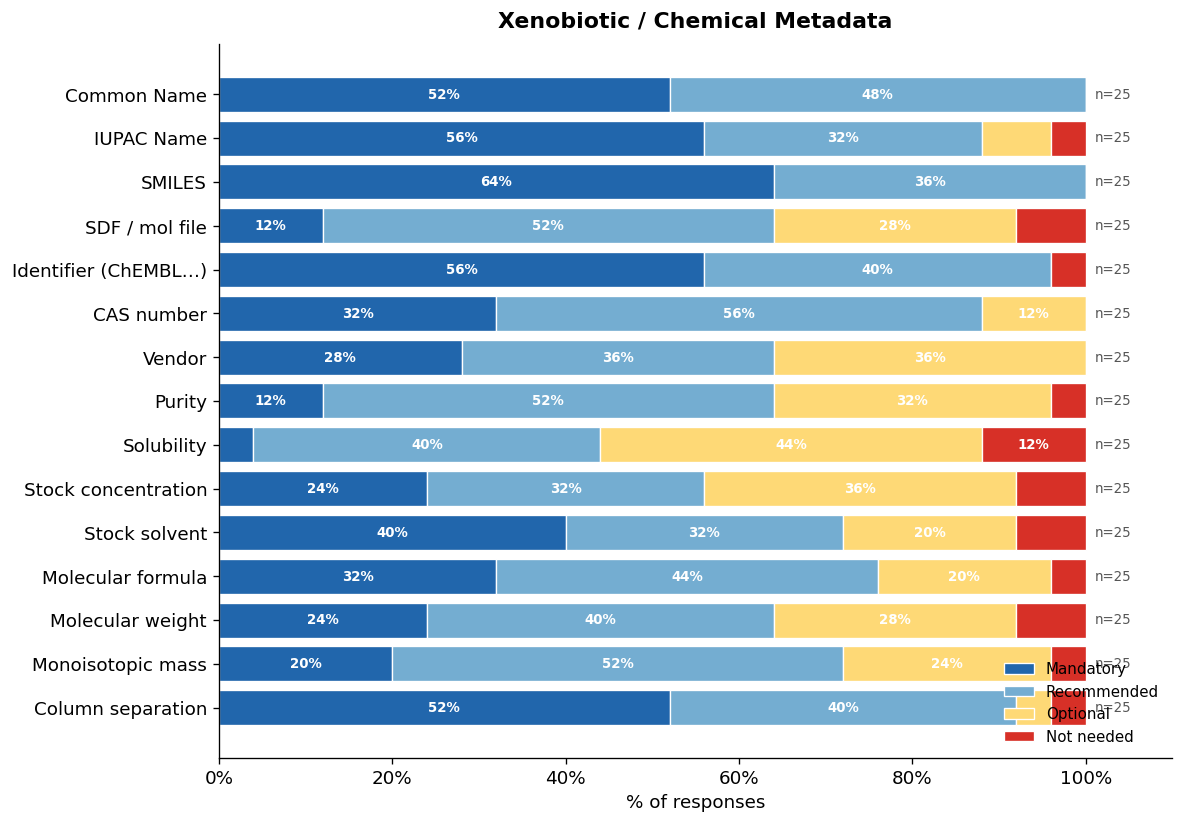

In [87]:
XB_COLS = {
    'Common Name'             : COL['xb_common_name'],
    'IUPAC Name'              : COL['xb_iupac'],
    'SMILES'                  : COL['xb_smiles'],
    'SDF / mol file'          : COL['xb_sdf'],
    'Identifier (ChEMBL…)'    : COL['xb_identifier'],
    'CAS number'              : COL['xb_cas'],
    'Vendor'                  : COL['xb_vendor'],
    'Purity'                  : COL['xb_purity'],
    'Solubility'              : COL['xb_solubility'],
    'Stock concentration'     : COL['xb_stock_conc'],
    'Stock solvent'           : COL['xb_stock_solvent'],
    'Molecular formula'       : COL['xb_mol_formula'],
    'Molecular weight'        : COL['xb_mol_weight'],
    'Monoisotopic mass'       : COL['xb_mono_mass'],
    'Column separation'       : COL['xb_column_sep'],
}

fig, ax = rating_stacked_bar(XB_COLS, 'Xenobiotic / Chemical Metadata', figsize=(10, 7))
plt.savefig('fig_metadata_xenobiotic.png', bbox_inches='tight')
plt.show()

## 9 · Importance of Standardization (1–5 scale)

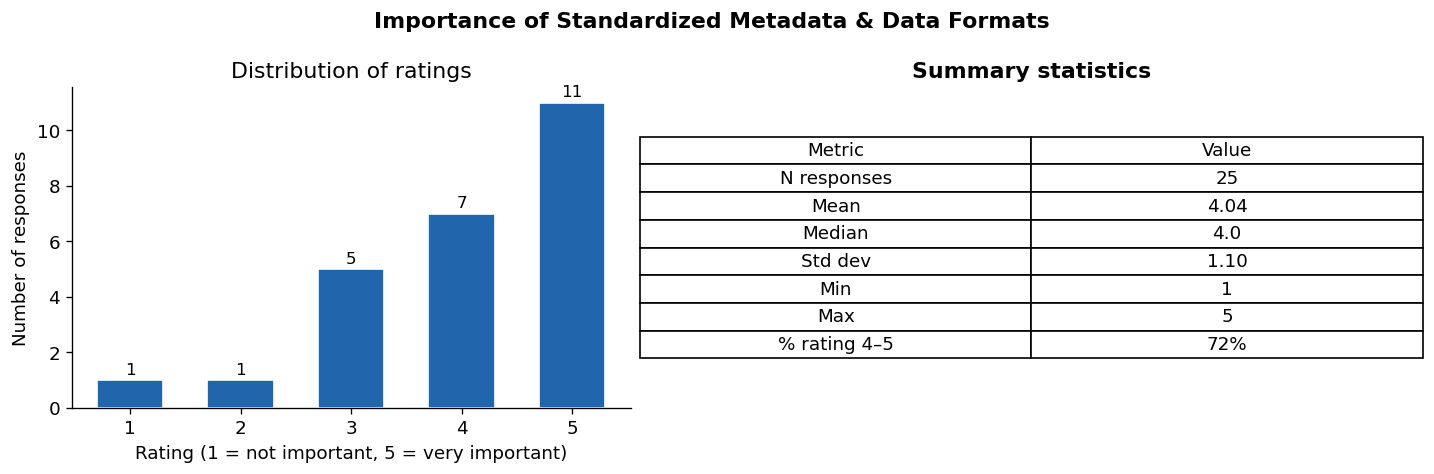

In [88]:
imp = df[COL['importance']].dropna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Importance of Standardized Metadata & Data Formats', fontweight='bold')

# Distribution bar
ax = axes[0]
counts = imp.value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#2166ac', edgecolor='white', width=0.6)
ax.set_xlabel('Rating (1 = not important, 5 = very important)')
ax.set_ylabel('Number of responses')
ax.set_title('Distribution of ratings')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + 0.1, str(y), ha='center', va='bottom', fontsize=10)

# Summary stats
ax = axes[1]
ax.axis('off')
stats = imp.describe()
table_data = [
    ['Metric', 'Value'],
    ['N responses', f"{int(stats['count'])}"],
    ['Mean',        f"{stats['mean']:.2f}"],
    ['Median',      f"{stats['50%']:.1f}"],
    ['Std dev',     f"{stats['std']:.2f}"],
    ['Min',         f"{int(stats['min'])}"],
    ['Max',         f"{int(stats['max'])}"],
    ['% rating 4–5', f"{(imp >= 4).mean()*100:.0f}%"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)
ax.set_title('Summary statistics', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_importance.png', bbox_inches='tight')
plt.show()

## 10 · Barriers & Support Needs


Other barrier responses:
  - lack of sense of community. Taking as example MIBIG part of its success is community feeling an active part of it (through hackathons seeing other people use the database codes on their papers building tools associated etc across different global institutions).
  - time constraints
  - for some like endogenous and also xenobiotic chemicals there are conflicting standards and as non-chemist I cannot judge which is best

Other support type responses:
  - associated user friendly databases sense of global community hackathons and community consideration


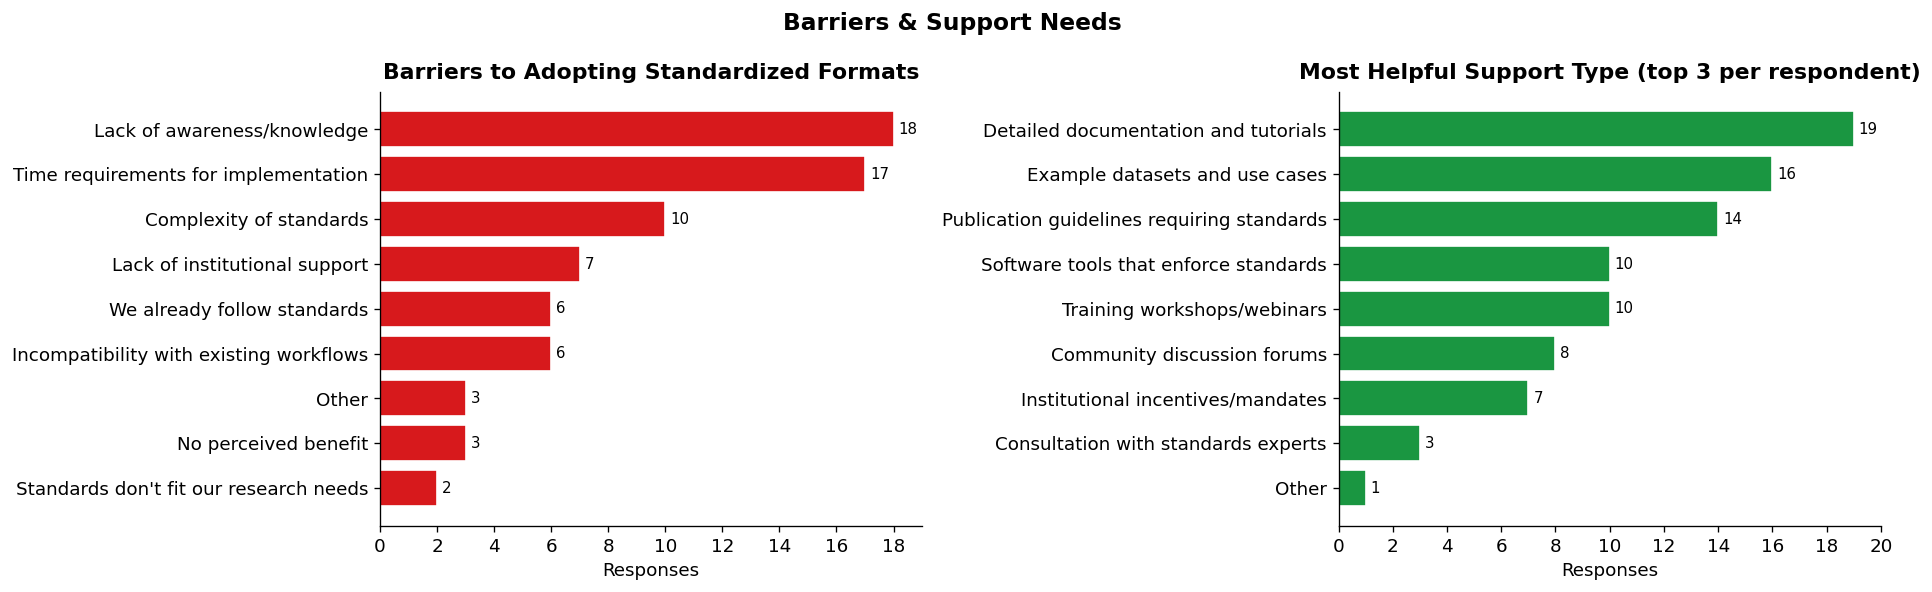


Would benefit from guidelines & templates (1–5 scale):
  Mean:         4.48
  Median:       5.0
  % rating 4-5: 92%
Would you benefit from guidelines and templates for implementing microbiome data standards?
3     2
4     9
5    14


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Barriers & Support Needs', fontsize=14, fontweight='bold')

# Barriers
ax = axes[0]
counts = split_known_options(df[COL['barriers']], BARRIERS_OPTIONS, other_label='Other').value_counts()
bar_h(counts, 'Barriers to Adopting Standardized Formats', ax, color='#d7191c')

# Print free-text 'Other' responses
_others_b = get_other_texts(df[COL['barriers']], BARRIERS_OPTIONS)
if _others_b:
    print('\nOther barrier responses:')
    for _t in _others_b:
        print(f'  - {_t}')

_others_s = get_other_texts(df[COL['support_type']], SUPPORT_TYPE_OPTIONS)
if _others_s:
    print('\nOther support type responses:')
    for _t in _others_s:
        print(f'  - {_t}')

# Benefit from guidelines?
ax2 = axes[1]
counts2 = split_known_options(df[COL['support_type']], SUPPORT_TYPE_OPTIONS, other_label='Other').value_counts()
bar_h(counts2, 'Most Helpful Support Type (top 3 per respondent)', ax2, color='#1a9641')

plt.tight_layout()
plt.savefig('fig_barriers_support.png', bbox_inches='tight')
plt.show()

# Benefit from guidelines — numeric summary (1–5 scale)
benefit = df[COL['benefit_guide']].dropna().astype(int)
print(f'\nWould benefit from guidelines & templates (1–5 scale):')
print(f'  Mean:         {benefit.mean():.2f}')
print(f'  Median:       {benefit.median():.1f}')
print(f'  % rating 4-5: {(benefit >= 4).mean()*100:.0f}%')
print(benefit.value_counts().sort_index().to_string())

## 11 · Community Engagement

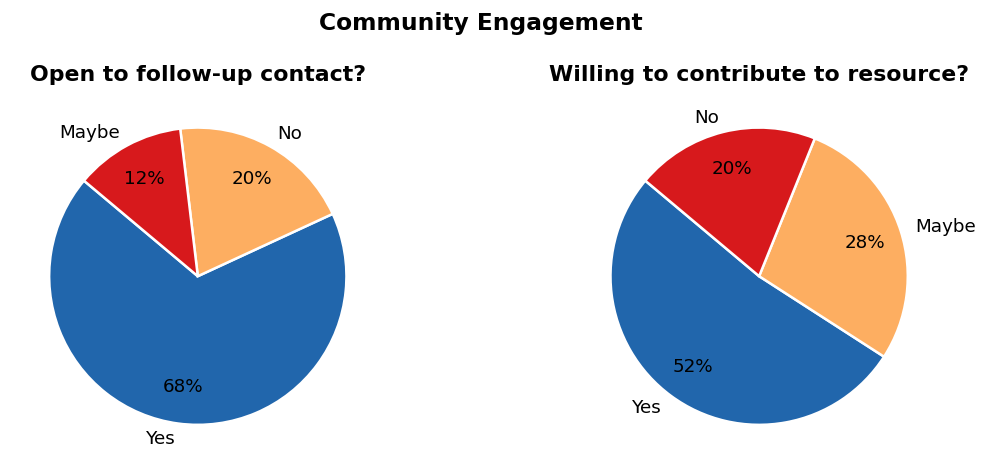


Respondents who provided an email for follow-up: 17


In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Community Engagement', fontsize=14, fontweight='bold')

wedge_colors = ['#2166ac', '#fdae61', '#d7191c', '#1a9641']

for ax, key, title in [
    (axes[0], 'contact_ok', 'Open to follow-up contact?'),
    (axes[1], 'contribute', 'Willing to contribute to resource?'),
]:
    counts = df[COL[key]].value_counts()
    ax.pie(counts.values, labels=counts.index, colors=wedge_colors[:len(counts)],
           autopct='%1.0f%%', startangle=140, pctdistance=0.75,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_engagement.png', bbox_inches='tight')
plt.show()

# Email count (without showing addresses)
emails = df[COL['email']].dropna()
emails = emails[emails.str.strip() != '']
print(f'\nRespondents who provided an email for follow-up: {len(emails)}')

## 12 · Priority Heatmap — All Metadata Sections Combined

A single heatmap summarising the **% Mandatory** rating across every parameter.

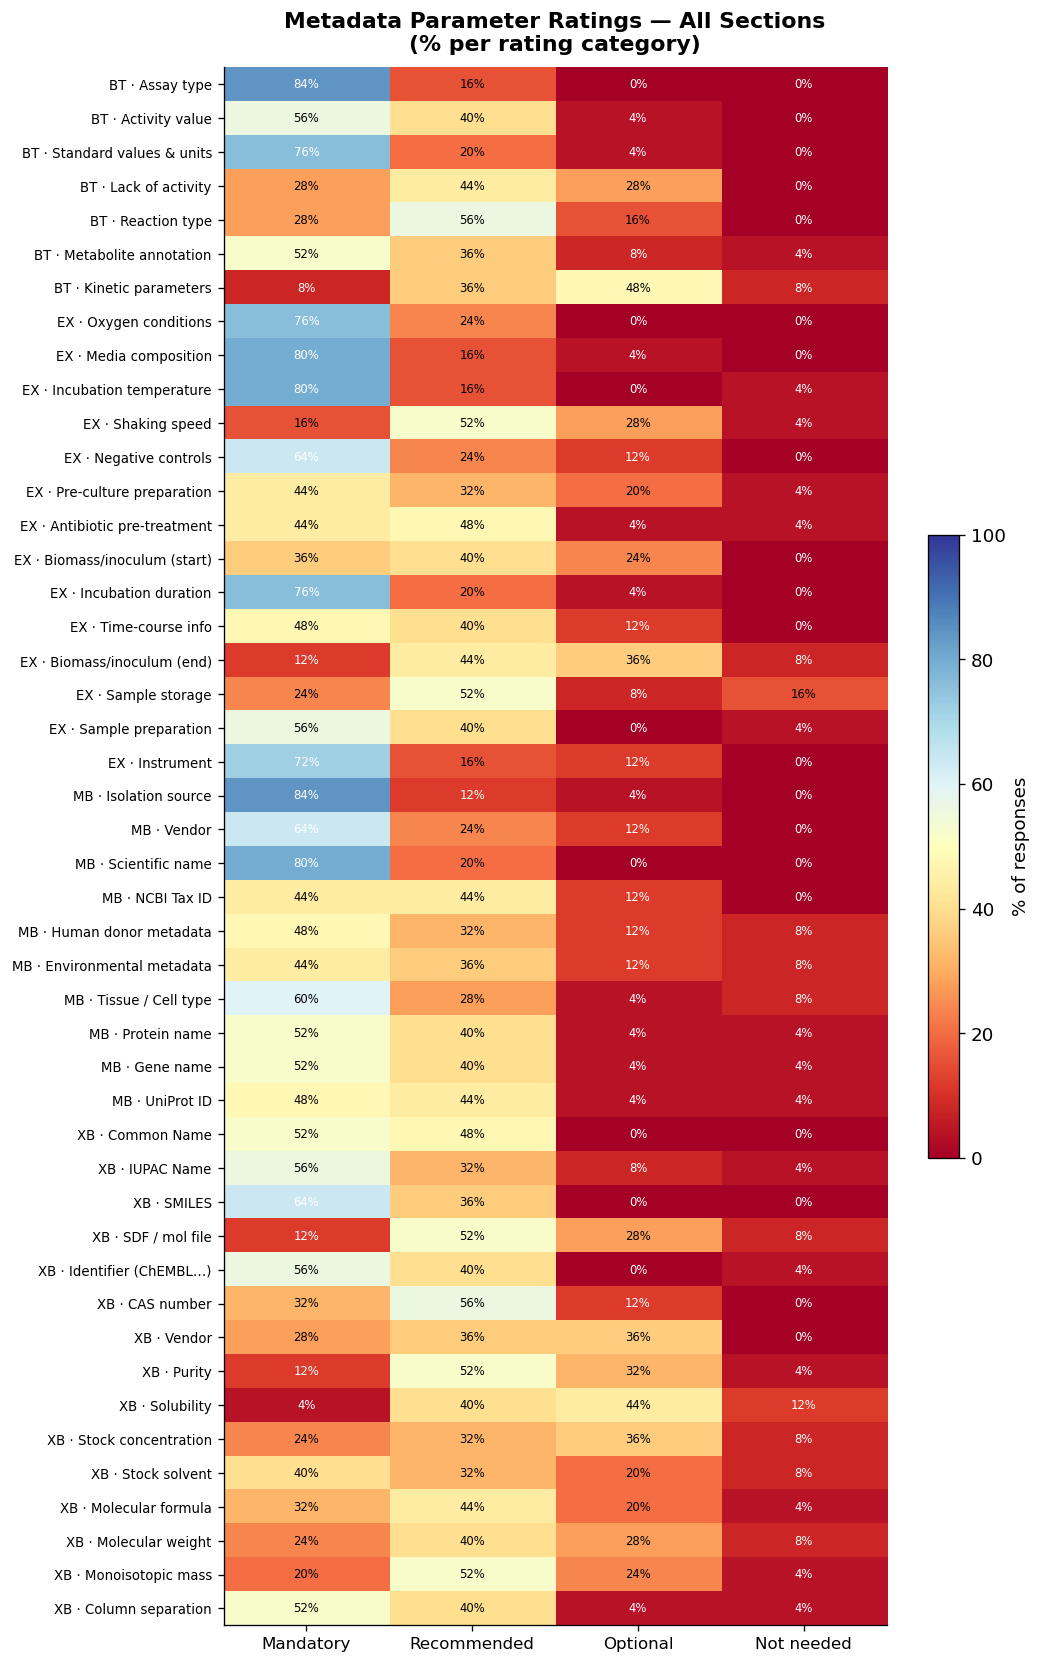

In [91]:
all_sections = {
    # Biotransformation
    'BT · Assay type'              : COL['bt_assay_type'],
    'BT · Activity value'          : COL['bt_activity_value'],
    'BT · Standard values & units' : COL['bt_std_values_units'],
    'BT · Lack of activity'        : COL['bt_lack_activity'],
    'BT · Reaction type'           : COL['bt_reaction_type'],
    'BT · Metabolite annotation'   : COL['bt_metabolite_annot'],
    'BT · Kinetic parameters'      : COL['bt_kinetic_params'],
    # Experiment
    'EX · Oxygen conditions'       : COL['ex_oxygen'],
    'EX · Media composition'       : COL['ex_media'],
    'EX · Incubation temperature'  : COL['ex_temperature'],
    'EX · Shaking speed'           : COL['ex_shaking'],
    'EX · Negative controls'       : COL['ex_neg_controls'],
    'EX · Pre-culture preparation' : COL['ex_preculture'],
    'EX · Antibiotic pre-treatment': COL['ex_antibiotic'],
    'EX · Biomass/inoculum (start)': COL['ex_biomass_start'],
    'EX · Incubation duration'     : COL['ex_duration'],
    'EX · Time-course info'        : COL['ex_timecourse'],
    'EX · Biomass/inoculum (end)'  : COL['ex_biomass_end'],
    'EX · Sample storage'          : COL['ex_storage'],
    'EX · Sample preparation'      : COL['ex_sample_prep'],
    'EX · Instrument'              : COL['ex_instrument'],
    # Microbiome
    'MB · Isolation source'        : COL['mb_source'],
    'MB · Vendor'                  : COL['mb_vendor'],
    'MB · Scientific name'         : COL['mb_sci_name'],
    'MB · NCBI Tax ID'             : COL['mb_ncbi_tax'],
    'MB · Human donor metadata'    : COL['mb_human_donor'],
    'MB · Environmental metadata'  : COL['mb_env_meta'],
    'MB · Tissue / Cell type'      : COL['mb_tissue'],
    'MB · Protein name'            : COL['mb_protein'],
    'MB · Gene name'               : COL['mb_gene'],
    'MB · UniProt ID'              : COL['mb_uniprot'],
    # Xenobiotic
    'XB · Common Name'             : COL['xb_common_name'],
    'XB · IUPAC Name'              : COL['xb_iupac'],
    'XB · SMILES'                  : COL['xb_smiles'],
    'XB · SDF / mol file'          : COL['xb_sdf'],
    'XB · Identifier (ChEMBL…)'    : COL['xb_identifier'],
    'XB · CAS number'              : COL['xb_cas'],
    'XB · Vendor'                  : COL['xb_vendor'],
    'XB · Purity'                  : COL['xb_purity'],
    'XB · Solubility'              : COL['xb_solubility'],
    'XB · Stock concentration'     : COL['xb_stock_conc'],
    'XB · Stock solvent'           : COL['xb_stock_solvent'],
    'XB · Molecular formula'       : COL['xb_mol_formula'],
    'XB · Molecular weight'        : COL['xb_mol_weight'],
    'XB · Monoisotopic mass'       : COL['xb_mono_mass'],
    'XB · Column separation'       : COL['xb_column_sep'],
}

rows = []
for label, col in all_sections.items():
    vc = df[col].value_counts()
    total = vc.sum()
    row = {r: vc.get(r, 0) / total * 100 for r in RATING_ORDER}
    row['Parameter'] = label
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Parameter')[RATING_ORDER]

fig, ax = plt.subplots(figsize=(9, 14))
im = ax.imshow(summary.values, aspect='auto', cmap='RdYlBu', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='% of responses', shrink=0.4)
ax.set_xticks(range(len(RATING_ORDER)))
ax.set_xticklabels(RATING_ORDER, fontsize=10)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary.index, fontsize=8)
ax.set_title('Metadata Parameter Ratings — All Sections\n(% per rating category)', fontweight='bold', pad=10)

# Annotate cells
for i in range(len(summary)):
    for j in range(len(RATING_ORDER)):
        v = summary.values[i, j]
        color = 'white' if v > 60 or v < 15 else 'black'
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('fig_heatmap_all_metadata.png', bbox_inches='tight')
plt.show()

## 13 · Open-ended Feedback

In [92]:
open_ended = {
    'Additional BT/Bioactivity parameters' : COL['bt_freetext'],
    'Additional Experiment parameters'     : COL['ex_freetext'],
    'Additional Microbiome parameters'     : COL['mb_freetext'],
    'Additional Xenobiotic parameters'     : COL['xb_freetext'],
    'New standards needed'                 : COL['new_standards'],
    'Specific features for implementation' : COL['specific_features'],
}

for section, col in open_ended.items():
    responses = df[col].dropna().str.strip()
    responses = responses[responses != '']
    print(f"\n{'='*70}")
    print(f"  {section} ({len(responses)} responses)")
    print(f"{'='*70}")
    for i, r in enumerate(responses, 1):
        print(f"  [{i}] {r}")


  Additional BT/Bioactivity parameters (4 responses)
  [1] Biotransformation genes defined, or otherwise genome information accessible for strain/microbiome sample. At least microbiome taxonomic composition / strain ID to be identifiable and accesible. If pathway is complete or incomplete. Enzymatic classes. Chemical moieties involved /type reaction to subset.
  [2] Organism, concentration
  [3] Involved genes/enzymes
  [4] Biotransformation is key, but bioactivity is hard to define. Most often it can only be speculated which bacteria did what. For me the species-specific information is so far under researched.

  Additional Experiment parameters (4 responses)
  [1] if solid or liquid media state , if from supernatant or intracellularly
  [2] measurement parameters, precursor concentration
  [3] Culture volume (optional)
  [4] The measurement of metabolites or proteins leads to an instrument-specific  and a evaluation tool-specific bias, so the data should be stored as raw data

  Add

## 14 · Top-line Summary Table

In [93]:
# Rank all metadata parameters by % Mandatory
summary_sorted = summary.sort_values('Mandatory', ascending=False)

print(f"{'Parameter':<40} {'Mandatory':>10} {'Recommended':>12} {'Optional':>9} {'Not needed':>10}")
print('-' * 85)
for param, row in summary_sorted.iterrows():
    print(f"{param:<40} {row['Mandatory']:>9.0f}% {row['Recommended']:>11.0f}% {row['Optional']:>8.0f}% {row['Not needed']:>9.0f}%")

Parameter                                 Mandatory  Recommended  Optional Not needed
-------------------------------------------------------------------------------------
BT · Assay type                                 84%          16%        0%         0%
MB · Isolation source                           84%          12%        4%         0%
EX · Media composition                          80%          16%        4%         0%
EX · Incubation temperature                     80%          16%        0%         4%
MB · Scientific name                            80%          20%        0%         0%
BT · Standard values & units                    76%          20%        4%         0%
EX · Oxygen conditions                          76%          24%        0%         0%
EX · Incubation duration                        76%          20%        4%         0%
EX · Instrument                                 72%          16%       12%         0%
XB · SMILES                                     64%   